#  Sales Performance Dashboard — Analysis Notebook
**Author:** Rudra Parmar

**Tools:** Python, Pandas, Matplotlib, Power BI  
**Dataset:** 5,000 rows of retail sales data (2024)  

---
## Project Steps
1. Load & Explore Raw Data
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Key Insights & Business Recommendations

In [3]:
import os

# Set correct working directory
os.chdir(r'C:\Users\rudra\Sales-Dashboard')

# Create all needed folders
os.makedirs('Data', exist_ok=True)
os.makedirs('Outputs', exist_ok=True)
os.makedirs('Notebooks', exist_ok=True)
os.makedirs('Reports', exist_ok=True)

print(' Working directory:', os.getcwd())
print('All folders ready!')

 Working directory: C:\Users\rudra\Sales-Dashboard
All folders ready!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(' Libraries imported successfully!')

 Libraries imported successfully!


In [5]:
from pathlib import Path

# Load the dataset
data_path = Path('../Data/raw_sales_data.csv')
if not data_path.exists():
	search_paths = [
		Path('raw_sales_data.csv'),
		Path('Data') / 'raw_sales_data.csv',
		Path('../Data') / 'raw_sales_data.csv',
		Path('..') / 'Data' / 'raw_sales_data.csv'
	]
	data_path = next((p for p in search_paths if p.exists()), None)

if data_path is None or not data_path.exists():
	raise FileNotFoundError(
		'raw_sales_data.csv not found. Checked: '
		f'{", ".join(str(p) for p in search_paths)}. '
		'Place the file in one of these locations or update the path.'
	)

df = pd.read_csv(data_path)
print(f'Loaded data from: {data_path}')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Date range: {df["Date"].min()} → {df["Date"].max()}')
df.head()

Loaded data from: Data\raw_sales_data.csv
Shape: 5000 rows × 12 columns
Date range: 2024-01-01 → 2024-12-30


,Order_ID,Date,Region,Sales_Rep,Product,Category,Quantity,Unit_Price,Discount_Pct,Revenue,Cost,Profit
0,ORD-10000,2024-04-24,East,Sneha Joshi,Mobile,Electronics,1,20414,0.00,20414,13300,7114
1,ORD-10001,2024-04-21,North,Priya Singh,Headphones,Accessories,1,4259,10.00,3833,2359,1474
2,ORD-10002,2024-01-04,West,Vikram Rao,Headphones,Accessories,4,4733,0.00,18932,12395,6537
3,ORD-10003,2024-02-19,North,Arjun Mehta,Mouse,Peripherals,2,1166,0.00,2332,1494,838
4,ORD-10004,2024-11-17,North,Vikram Rao,Mobile,Electronics,7,22521,0.00,157647,100359,57288


In [6]:
# Check data types
df.dtypes

Order_ID            str
Date                str
Region              str
Sales_Rep           str
Product             str
Category            str
Quantity          int64
Unit_Price        int64
Discount_Pct    float64
Revenue           int64
Cost              int64
Profit            int64
dtype: object

In [7]:
# Check for null values
print(' Null Values:')
print(df.isnull().sum())
print(f'\nTotal nulls: {df.isnull().sum().sum()}')

 Null Values:
Order_ID          0
Date              0
Region            0
Sales_Rep       167
Product           0
Category          0
Quantity          0
Unit_Price        0
Discount_Pct     91
Revenue           0
Cost              0
Profit            0
dtype: int64

Total nulls: 258


In [8]:
# Basic statistics
df[['Quantity','Unit_Price','Discount_Pct','Revenue','Cost','Profit']].describe()

,Quantity,Unit_Price,Discount_Pct,Revenue,Cost,Profit
count,"5,000.00","5,000.00","4,909.00","5,000.00","5,000.00","5,000.00"
mean,5.45,"15,383.83",5.01,"79,744.24","52,583.99","27,160.25"
std,2.88,"16,362.67",5.74,"105,023.42","69,698.58","36,678.04"
min,1.00,"1,080.00",0.00,922.00,611.00,191.00
25%,3.00,"4,167.00",0.00,"14,039.50","9,118.50","4,593.50"
50%,5.00,"10,944.00",5.00,"39,455.50","25,914.00","12,949.00"
75%,8.00,"19,682.75",10.00,"103,513.50","68,523.50","34,006.75"
max,10.00,"60,452.00",15.00,"604,070.00","410,039.00","249,832.00"


In [9]:
# 1. Fix data types
df['Date']         = pd.to_datetime(df['Date'])
df['Discount_Pct'] = pd.to_numeric(df['Discount_Pct'], errors='coerce')
print(' Fixed: Date → datetime, Discount_Pct → numeric')

# 2. Handle null values
df['Sales_Rep']    = df['Sales_Rep'].fillna('Unassigned')
df['Discount_Pct'] = df['Discount_Pct'].fillna(0)
print(' Nulls filled: Sales_Rep → Unassigned, Discount_Pct → 0')

# 3. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f' Duplicates removed: {before - len(df)} rows dropped')

# 4. Add derived columns
df['Month']         = df['Date'].dt.to_period('M').astype(str)
df['Quarter']       = df['Date'].dt.to_period('Q').astype(str)
df['Month_Num']     = df['Date'].dt.month
df['Day_of_Week']   = df['Date'].dt.day_name()
df['Profit_Margin'] = (df['Profit'] / df['Revenue'] * 100).round(2)
print(' New columns added: Month, Quarter, Day_of_Week, Profit_Margin')

# 5. Validate
assert df['Revenue'].min() > 0
assert df['Quantity'].min() >= 1
print(' Validation passed!')

print(f'\n Clean dataset: {df.shape[0]} rows × {df.shape[1]} columns')

 Fixed: Date → datetime, Discount_Pct → numeric
 Nulls filled: Sales_Rep → Unassigned, Discount_Pct → 0
 Duplicates removed: 0 rows dropped
 New columns added: Month, Quarter, Day_of_Week, Profit_Margin
 Validation passed!

 Clean dataset: 5000 rows × 17 columns


In [10]:
# Confirm no nulls remain
print('Remaining nulls:', df.isnull().sum().sum())
df.head(3)

Remaining nulls: 0


,Order_ID,Date,Region,Sales_Rep,Product,Category,Quantity,Unit_Price,Discount_Pct,Revenue,Cost,Profit,Month,Quarter,Month_Num,Day_of_Week,Profit_Margin
0,ORD-10000,2024-04-24,East,Sneha Joshi,Mobile,Electronics,1,20414,0.00,20414,13300,7114,2024-04,2024Q2,4,Wednesday,34.85
1,ORD-10001,2024-04-21,North,Priya Singh,Headphones,Accessories,1,4259,10.00,3833,2359,1474,2024-04,2024Q2,4,Sunday,38.46
2,ORD-10002,2024-01-04,West,Vikram Rao,Headphones,Accessories,4,4733,0.00,18932,12395,6537,2024-01,2024Q1,1,Thursday,34.53


In [11]:
# Save cleaned file
df.to_csv('Data/cleaned_sales_data.csv', index=False)
print(' Saved: Data/cleaned_sales_data.csv')

 Saved: Data/cleaned_sales_data.csv


In [12]:
# Color palette
BLUE   = '#1F4E79'
ACCENT = '#2E75B6'
ORANGE = '#ED7D31'
COLORS = ['#1F4E79','#2E75B6','#5BA3D9','#9DC3E6','#BDD7EE']

def fmt_inr(x, _):
    if x >= 1e7: return f'₹{x/1e7:.1f}Cr'
    if x >= 1e5: return f'₹{x/1e5:.0f}L'
    return f'₹{x:,.0f}'

plt.rcParams['figure.dpi'] = 120
print(' Chart settings ready')

 Chart settings ready


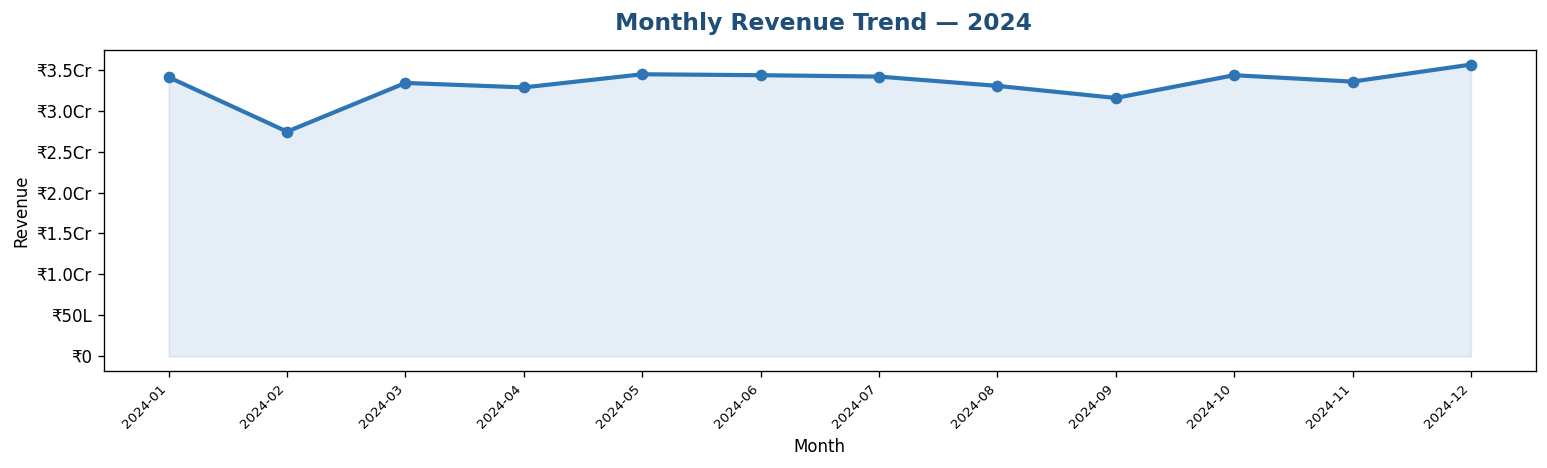

Best month: 2024-12 — ₹35,622,009


In [13]:
# CHART 1: Monthly Revenue Trend 
monthly = df.groupby('Month')['Revenue'].sum().reset_index().sort_values('Month')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(len(monthly)), monthly['Revenue'],
        color=ACCENT, linewidth=2.5, marker='o', markersize=6)
ax.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.12, color=ACCENT)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Month'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title(' Monthly Revenue Trend — 2024',
             fontsize=14, fontweight='bold', color=BLUE, pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue')
plt.tight_layout()
out_dir = Path('../Outputs')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best month: {monthly.loc[monthly["Revenue"].idxmax(), "Month"]} — ₹{monthly["Revenue"].max():,.0f}')

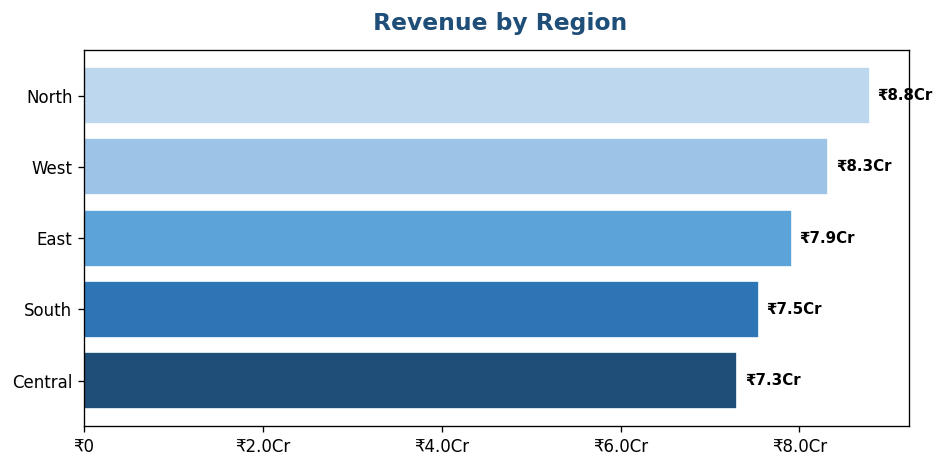

Top region: North — ₹87,869,949


In [14]:
# CHART 2: Revenue by Region 
reg = df.groupby('Region')['Revenue'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(reg.index, reg.values, color=COLORS[:len(reg)], edgecolor='white')
for bar, val in zip(bars, reg.values):
    ax.text(bar.get_width() + reg.values.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            fmt_inr(val, None), va='center', fontsize=9, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title(' Revenue by Region', fontsize=14, fontweight='bold', color=BLUE, pad=12)
plt.tight_layout()
plt.savefig('../Outputs/chart2_revenue_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top region: {reg.idxmax()} — ₹{reg.max():,.0f}')

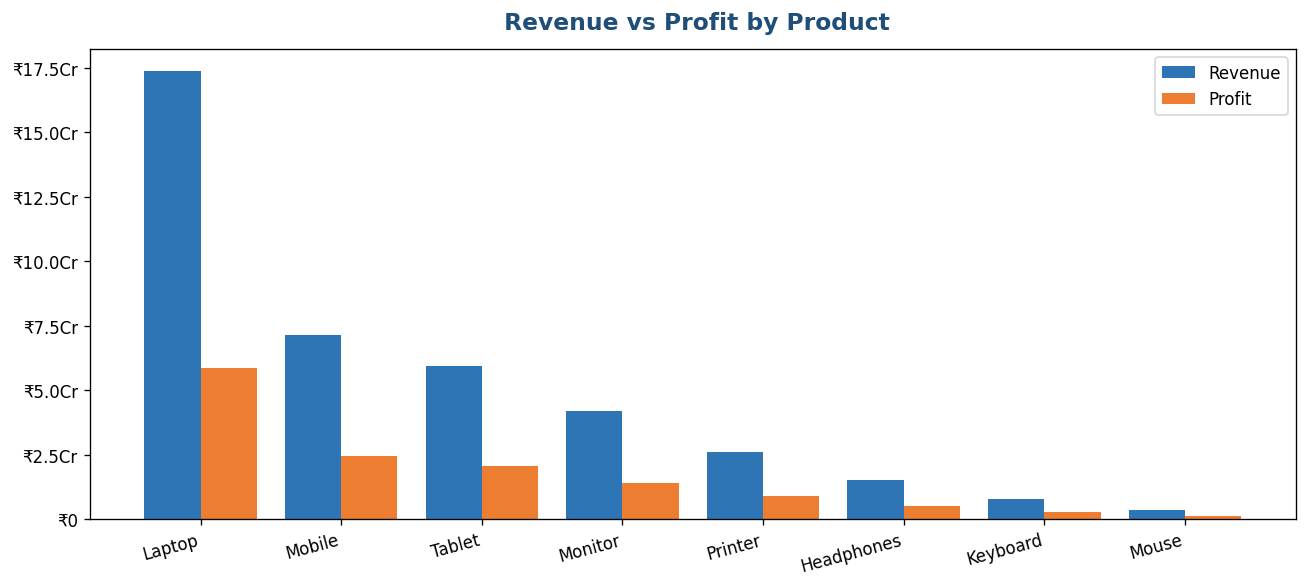

Top product: Laptop


In [15]:
#  CHART 3: Product Revenue vs Profit 
prod = df.groupby('Product')[['Revenue','Profit']].sum().sort_values('Revenue', ascending=False)

x = range(len(prod))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - 0.2 for i in x], prod['Revenue'], width=0.4, label='Revenue', color=ACCENT)
ax.bar([i + 0.2 for i in x], prod['Profit'],  width=0.4, label='Profit',  color=ORANGE)
ax.set_xticks(list(x))
ax.set_xticklabels(prod.index, rotation=15, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title(' Revenue vs Profit by Product',
             fontsize=14, fontweight='bold', color=BLUE, pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('../Outputs/chart3_product_revenue_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top product: {prod["Revenue"].idxmax()}')

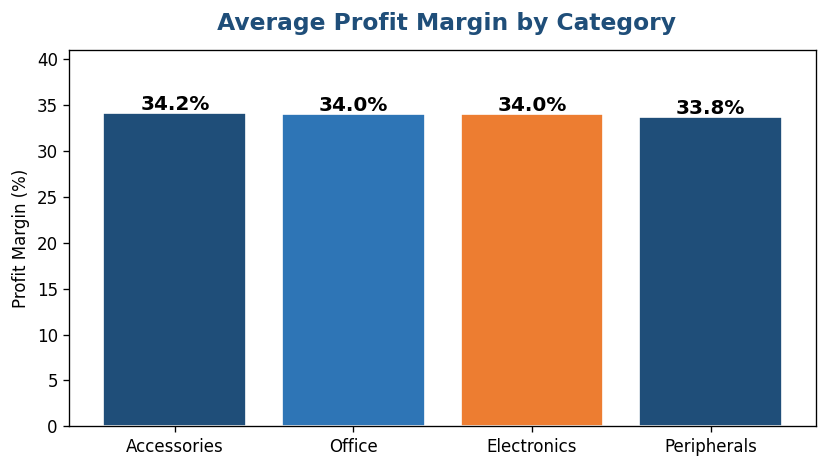

Highest margin: Accessories at 34.2%


In [16]:
#  CHART 4: Profit Margin by Category 
cat = df.groupby('Category')['Profit_Margin'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cat.index, cat.values,
              color=[BLUE, ACCENT, ORANGE][:len(cat)], edgecolor='white')
for bar, val in zip(bars, cat.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title(' Average Profit Margin by Category',
             fontsize=14, fontweight='bold', color=BLUE, pad=12)
ax.set_ylabel('Profit Margin (%)')
ax.set_ylim(0, cat.values.max() * 1.2)
plt.tight_layout()
out_dir = Path('../Outputs')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'chart4_profit_margin_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Highest margin: {cat.idxmax()} at {cat.max():.1f}%')

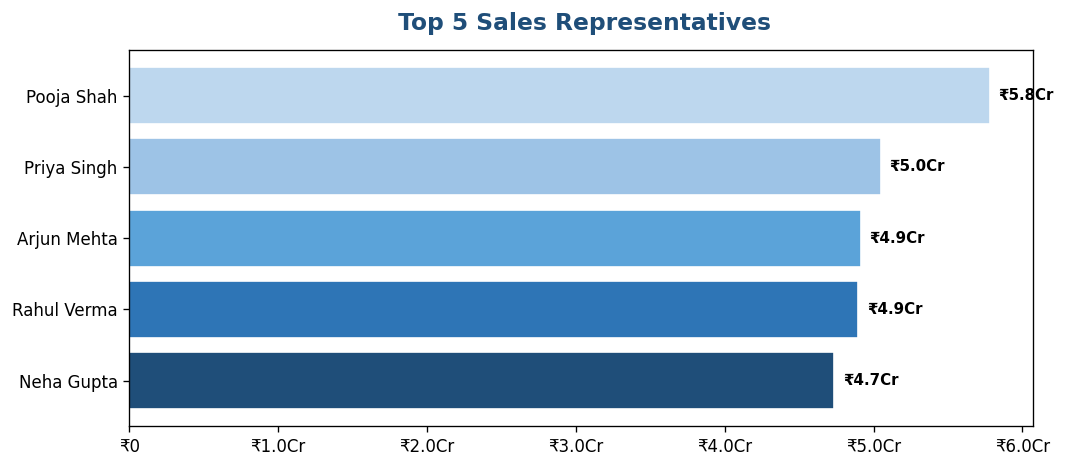

Top rep: Pooja Shah — ₹57,787,162


In [17]:
# CHART 5: Top 5 Sales Representatives 
rep = (df[df['Sales_Rep'] != 'Unassigned']
       .groupby('Sales_Rep')['Revenue'].sum()
       .nlargest(5).sort_values())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(rep.index, rep.values, color=COLORS[:5], edgecolor='white')
for bar, val in zip(bars, rep.values):
    ax.text(bar.get_width() + rep.values.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            fmt_inr(val, None), va='center', fontsize=9, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_title(' Top 5 Sales Representatives',
             fontsize=14, fontweight='bold', color=BLUE, pad=12)
plt.tight_layout()
plt.savefig('../Outputs/chart5_top_salesreps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top rep: {rep.idxmax()} — ₹{rep.max():,.0f}')

In [18]:
# Chart 1
plt.savefig('Outputs/chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')

# Chart 2
plt.savefig('Outputs/chart2_revenue_by_region.png', dpi=150, bbox_inches='tight')

# Chart 3
plt.savefig('Outputs/chart3_product_revenue_profit.png', dpi=150, bbox_inches='tight')

# Chart 4
plt.savefig('Outputs/chart4_profit_margin_category.png', dpi=150, bbox_inches='tight')

# Chart 5
plt.savefig('Outputs/chart5_top_salesreps.png', dpi=150, bbox_inches='tight')

<Figure size 768x576 with 0 Axes>

In [19]:
print('=' * 55)
print('   FINAL INSIGHTS SUMMARY')
print('=' * 55)
print(f'   Total Orders   : {len(df):,}')
print(f'   Total Revenue  : ₹{df["Revenue"].sum():,.0f}')
print(f'   Total Profit   : ₹{df["Profit"].sum():,.0f}')
print(f'   Avg Margin     : {df["Profit_Margin"].mean():.1f}%')
print(f'   Best Month     : {df.groupby("Month")["Revenue"].sum().idxmax()}')
print(f'   Best Region    : {df.groupby("Region")["Revenue"].sum().idxmax()}')
print(f'   Best Product   : {df.groupby("Product")["Revenue"].sum().idxmax()}')
print(f'   Best Margin    : {df.groupby("Category")["Profit_Margin"].mean().idxmax()}')
print(f'   Top Sales Rep  : {df[df["Sales_Rep"]!="Unassigned"].groupby("Sales_Rep")["Revenue"].sum().idxmax()}')
print('=' * 55)

print('''
 BUSINESS RECOMMENDATIONS:

1. North region leads in revenue — replicate its sales
   strategy across underperforming regions.

2. Accessories have the highest profit margin — bundle
   them with Electronics to boost overall profitability.

3. Laptop is the top revenue driver — prioritize stock
   availability and run targeted promotions.

4. December shows peak sales — plan Q4 inventory and
   marketing campaigns well in advance.

5. Orders with 0% discount show better margins —
   review discount strategy to protect profitability.
''')

   FINAL INSIGHTS SUMMARY
   Total Orders   : 5,000
   Total Revenue  : ₹398,721,221
   Total Profit   : ₹135,801,250
   Avg Margin     : 34.0%
   Best Month     : 2024-12
   Best Region    : North
   Best Product   : Laptop
   Best Margin    : Accessories
   Top Sales Rep  : Pooja Shah

 BUSINESS RECOMMENDATIONS:

1. North region leads in revenue — replicate its sales
   strategy across underperforming regions.

2. Accessories have the highest profit margin — bundle
   them with Electronics to boost overall profitability.

3. Laptop is the top revenue driver — prioritize stock
   availability and run targeted promotions.

4. December shows peak sales — plan Q4 inventory and
   marketing campaigns well in advance.

5. Orders with 0% discount show better margins —
   review discount strategy to protect profitability.

